<a href="https://colab.research.google.com/github/denise-accuni/mulheres/blob/main/MINERA%C3%87%C3%83O_DE_TEXTOS_BNCC_E_BNCC_COMPUTA%C3%87%C3%83O_Outra_Biblioteca_para_PDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pdfplumber nltk unidecode scikit-learn pandas

In [ ]:
import sys
!{sys.executable} -m pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 19.8 MB/s eta 0:00:00


In [ ]:
import sys
!{sys.executable} -m pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 80.2 MB/s eta 0:00:00


Agora, vamos modificar a função `extrair_texto_pdf` para usar `fitz`.

In [ ]:
# ============================================================
# MINERAÇÃO DE TEXTOS - BNCC E BNCC COMPUTAÇÃO
# Etapas:
# 1. Ler PDFs
# 2. Limpar e normalizar os textos
# 3. Remover stopwords
# 4. Salvar textos limpos
# 5. Aplicar TF-IDF
# ============================================================


import pdfplumber # Keep for potential fallback or other uses, though not used in extrair_texto_pdf anymore
import fitz # Import PyMuPDF
import re
import os
import pandas as pd
from unidecode import unidecode
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Downloads necessários do NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# ============================================================
# 1. FUNÇÃO PARA EXTRAIR TEXTO DO PDF
#    MODIFICADO PARA USAR PyMuPDF (fitz)
# ============================================================

def extrair_texto_pdf(caminho_pdf):
    texto = ""
    try:
        with fitz.open(caminho_pdf) as doc:
            for pagina in doc:
                conteudo = pagina.get_text("text")
                if conteudo:
                    texto += conteudo + "\n"
    except Exception as e:
        print(f"Erro ao extrair texto do PDF {caminho_pdf} com PyMuPDF: {e}")
        # Fallback ou raise do erro, dependendo da necessidade
    return texto

# ============================================================
# 2. FUNÇÃO DE LIMPEZA E NORMALIZAÇÃO
# ============================================================
# Aqui ocorre a limpeza inicial:
# - deixa tudo em minúsculas
# - remove acentos
# - remove números
# - remove pontuação
# - remove espaços extras
# ============================================================

def limpar_texto(texto):
    texto = texto.lower()
    texto = unidecode(texto)
    texto = re.sub(r'\d+', ' ', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'_', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# ============================================================
# 3. STOPWORDS
# ============================================================
# Atenção:
# Aqui você decide o que quer manter ou remover.
# "escola" e "basica" podem ser mantidas, se forem importantes
# para sua análise. Já termos muito genéricos podem ser removidos.
# ============================================================

stopwords_pt = set(stopwords.words('portuguese'))

stopwords_extras = {
    'art', 'sera', 'deve', 'podera', 'anos', 'ano', 'ensino', 'ensinar',
    'capitulo', 'secao', 'inciso', 'paragrafo', 'etc', 'etc.',
    'brasil', 'mec', 'cne', 'escola', 'basica', 'basico', 'nacional', 'base', 'curricular', 'comum',
    'computacao', 'bncc' # Adicionado 'computacao' e 'bncc' como stopwords
}

stopwords_total = stopwords_pt.union(stopwords_extras)

# ============================================================
# 4. TOKENIZAÇÃO E REMOÇÃO DE STOPWORDS
# ============================================================
# Aqui o texto limpo é quebrado em palavras (tokens),
# e as stopwords são removidas.
# Depois disso, o texto é remontado já filtrado.
# ============================================================

def preprocessar_texto(texto):
    tokens = word_tokenize(texto)
    tokens_filtrados = [
        t for t in tokens
        if t not in stopwords_total and len(t) > 2
    ]
    return " ".join(tokens_filtrados)

# ============================================================
# 5. LISTA DOS DOCUMENTOS
# ============================================================

arquivos = {
    "BNCC": "BNCC.pdf",
    "BNCC_Computacao": "BNCCComputacao.pdf"
    # Você pode acrescentar depois:
    # "Parecer_CNE": "Parecer_CNE.pdf",
    # "Diretrizes_SBC": "Diretrizes_SBC.pdf"
}

documentos_processados = {}

# ============================================================
# 6. PROCESSAMENTO COMPLETO DOS PDFs
# ============================================================
# Neste bloco, cada PDF passa por:
# extração -> limpeza -> remoção de stopwords -> texto final
# ============================================================

for nome_doc, caminho_pdf in arquivos.items():
    texto_bruto = extrair_texto_pdf(caminho_pdf)
    texto_limpo = limpar_texto(texto_bruto)
    texto_final = preprocessar_texto(texto_limpo)
    documentos_processados[nome_doc] = texto_final

    # opcional: salvar texto final limpo
    with open(f"{nome_doc}_limpo.txt", "w", encoding="utf-8") as f:
        f.write(texto_final)

print("Processamento concluído.")

# ============================================================
# 7. TF-IDF
# ============================================================
# É NESTE MOMENTO que o TF-IDF ocorre.
#
# O TF-IDF calcula a importância relativa dos termos em cada
# documento comparando:
# - frequência do termo dentro do documento (TF)
# - raridade do termo nos demais documentos (IDF)
#
# Ou seja:
# um termo recebe peso maior quando aparece bastante em um
# documento, mas não aparece com tanta força nos outros.
# ============================================================

nomes_docs = list(documentos_processados.keys())
textos_docs = list(documentos_processados.values())

vectorizer = TfidfVectorizer()
matriz_tfidf = vectorizer.fit_transform(textos_docs)

termos = vectorizer.get_feature_names_out()

# ============================================================
# 8. MOSTRAR OS TERMOS MAIS IMPORTANTES DE CADA DOCUMENTO
# ============================================================

for i, nome_doc in enumerate(nomes_docs):
    valores = matriz_tfidf[i].toarray()[0]
    df_doc = pd.DataFrame({
        "termo": termos,
        "tfidf": valores
    }).sort_values(by="tfidf", ascending=False)

    print(f"\nTop 20 termos mais relevantes em {nome_doc}:")
    print(df_doc.head(20))

    # salvar resultado em CSV
    df_doc.to_csv(f"TFIDF_{nome_doc}.csv", index=False, encoding="utf-8-sig")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Processamento concluído.

Top 20 termos mais relevantes em BNCC:
              termo     tfidf
3507     diferentes  0.262808
5577    habilidades  0.186012
11289        textos  0.172684
8900       praticas  0.165121
11933          vida  0.160768
5244    fundamental  0.158504
3857       educacao  0.140857
9135       producao  0.132664
6800         lingua  0.132664
1505          campo  0.127551
2397   conhecimento  0.123526
10766         sobre  0.120375
5328        generos  0.113379
5770    identificar  0.109346
7927        objetos  0.105249
8206         outros  0.103674
7688            nao  0.103043
5094          forma  0.101783
6802     linguagens  0.101783
1835       ciencias  0.098321

Top 20 termos mais relevantes em BNCC_Computacao:
                termo     tfidf
3507       diferentes  0.255324
2966            dados  0.214323
5576       habilidade  0.214323
8698             pode  0.193823
2238   computacionais  0.188592
9097        problemas  0.160277
10766           sobre  0.15654

In [ ]:
import sys
!{sys.executable} -m pip install unidecode

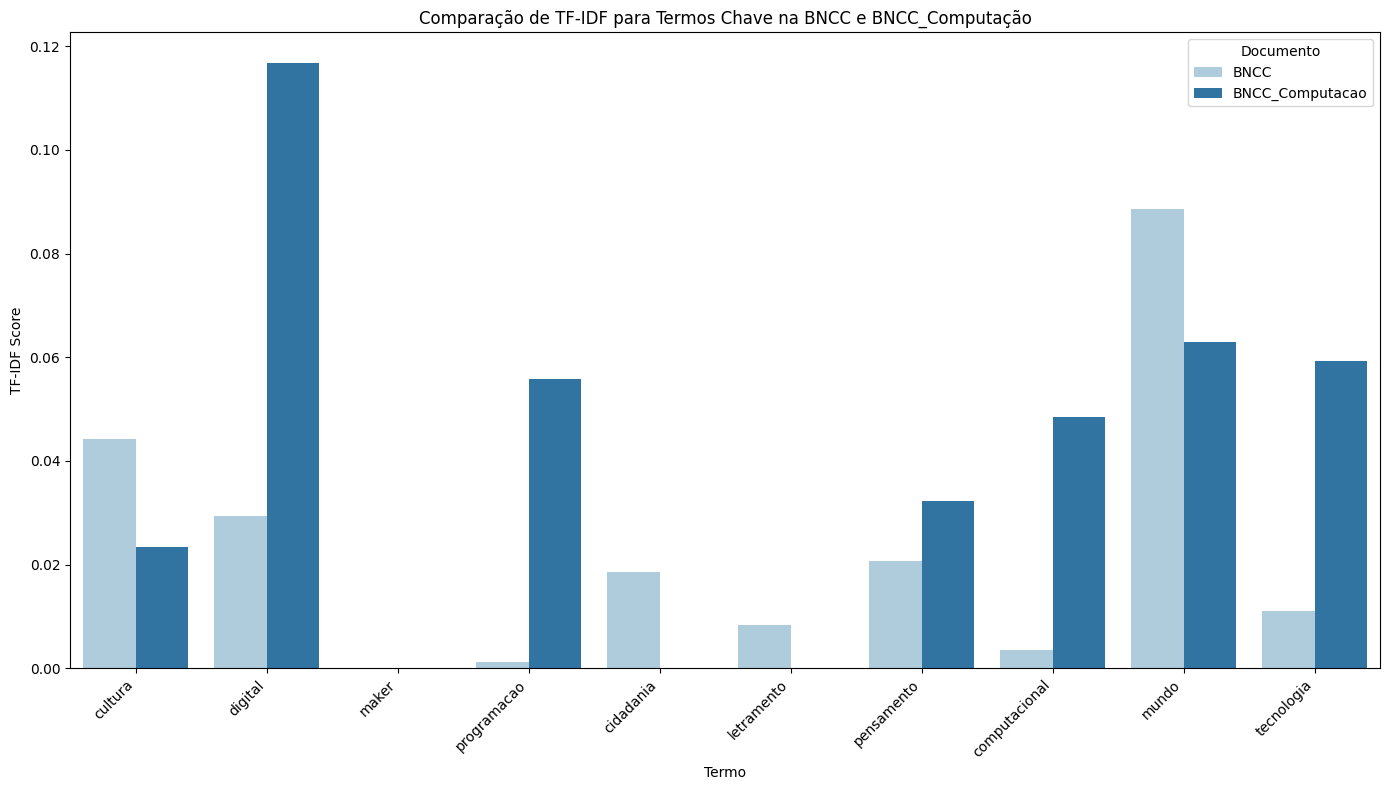

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregar os resultados TF-IDF para BNCC e BNCC_Computacao
df_bncc = pd.read_csv('TFIDF_BNCC.csv')
df_bncc_computacao = pd.read_csv('TFIDF_BNCC_Computacao.csv')

# Termos a serem comparados (reutilizando a lista da célula anterior)
search_terms = ['cultura', 'digital', 'maker', 'programacao', 'cidadania', 'letramento', 'pensamento', 'computacional', 'mundo', 'tecnologia']

# Filtrar os dataframes para os termos de busca
df_bncc_filtered = df_bncc[df_bncc['termo'].isin(search_terms)].copy()
df_bncc_computacao_filtered = df_bncc_computacao[df_bncc_computacao['termo'].isin(search_terms)].copy()

# Adicionar uma coluna de origem para identificar o documento
df_bncc_filtered['Documento'] = 'BNCC'
df_bncc_computacao_filtered['Documento'] = 'BNCC_Computacao'

# Combinar os dataframes para fácil plotagem
df_comparativo = pd.concat([df_bncc_filtered, df_bncc_computacao_filtered])

# Ajustar termos que podem ter pontuação ou diferentes formas se necessário (ex: 'computacional' vs 'computacao')
# Para uma comparação mais precisa, garanta que os termos em search_terms correspondam exatamente aos termos no CSV.
# Caso contrário, será necessário um pré-processamento mais robusto ou mapeamento de sinônimos.

# Preencher valores ausentes com 0 para termos que não aparecem em um dos documentos
df_pivot = df_comparativo.pivot_table(index='termo', columns='Documento', values='tfidf', fill_value=0).reset_index()
df_melted = df_pivot.melt(id_vars='termo', var_name='Documento', value_name='tfidf_score')

# Ordenar para melhor visualização
df_melted['termo'] = pd.Categorical(df_melted['termo'], categories=search_terms, ordered=True)
df_melted = df_melted.sort_values(by=['termo', 'Documento'])

# Criar o gráfico de barras comparativo
plt.figure(figsize=(14, 8))
sns.barplot(x='termo', y='tfidf_score', hue='Documento', data=df_melted, palette='Paired')
plt.title('Comparação de TF-IDF para Termos Chave na BNCC e BNCC_Computação')
plt.xlabel('Termo')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Documento')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1656/1187574225.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf', y='termo', data=df_bncc.head(20), palette='viridis')


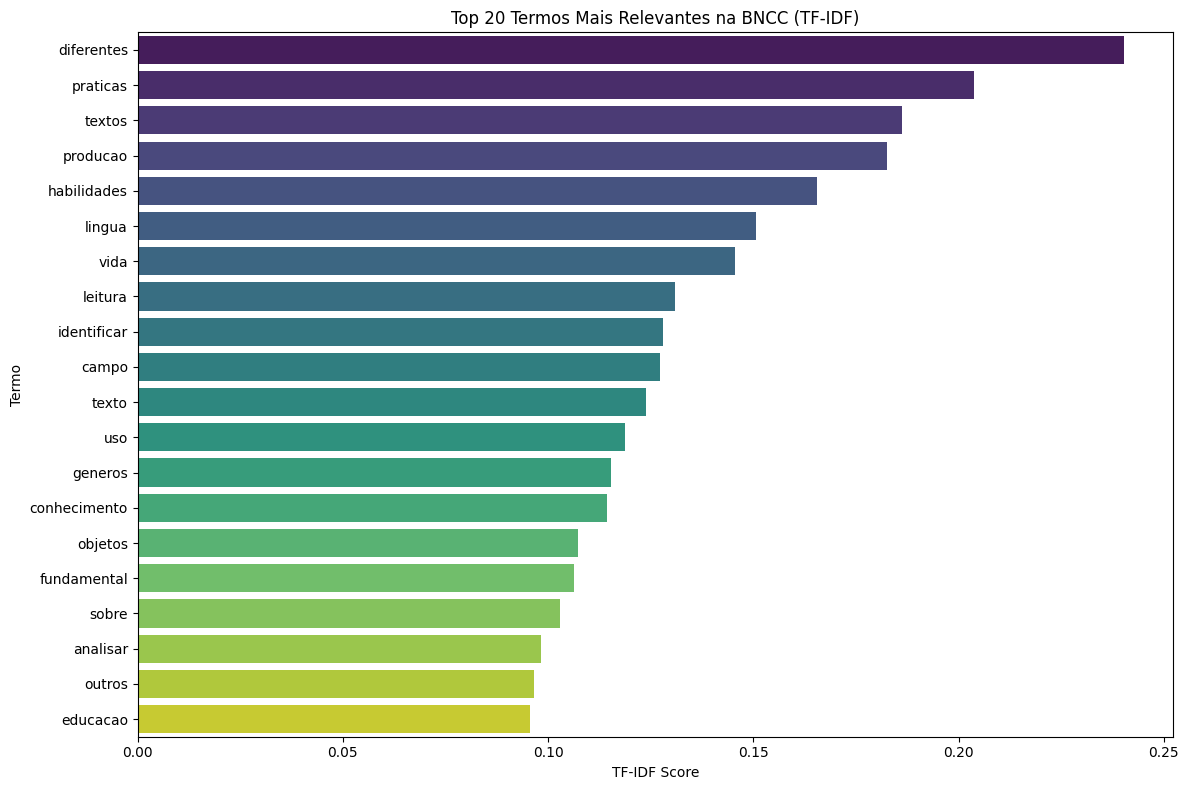

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the TF-IDF results for BNCC
df_bncc = pd.read_csv('TFIDF_BNCC.csv')

# Create a bar chart for the top 20 terms in BNCC
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf', y='termo', data=df_bncc.head(20), palette='viridis')
plt.title('Top 20 Termos Mais Relevantes na BNCC (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Termo')
plt.tight_layout()
plt.show()

/tmp/ipykernel_363/1155312053.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf', y='termo', data=df_bncc_computacao.head(20), palette='magma')


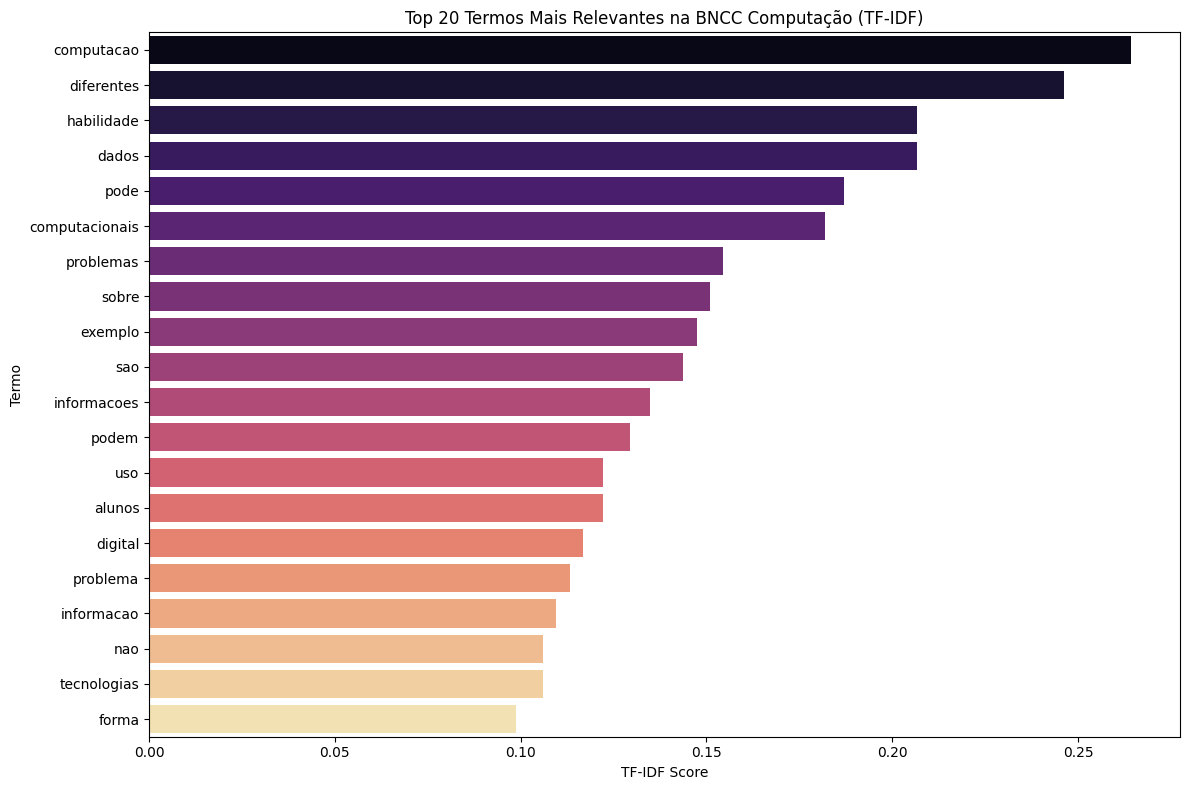

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the TF-IDF results for BNCC_Computacao
df_bncc_computacao = pd.read_csv('TFIDF_BNCC_Computacao.csv')

# Create a bar chart for the top 20 terms in BNCC_Computacao
plt.figure(figsize=(12, 8))
sns.barplot(x='tfidf', y='termo', data=df_bncc_computacao.head(20), palette='magma')
plt.title('Top 20 Termos Mais Relevantes na BNCC Computação (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Termo')
plt.tight_layout()
plt.show()

Estes gráficos de barras mostram os 20 termos com maior pontuação TF-IDF para cada documento. O TF-IDF (Term Frequency-Inverse Document Frequency) é uma medida estatística que reflete a importância de uma palavra em um documento em relação a uma coleção de documentos. Um score alto indica que a palavra é relevante para aquele documento específico e relativamente rara nos outros documentos da coleção.

Você pode usar essas visualizações para:

*   **Identificar tópicos chave**: Palavras com alto TF-IDF provavelmente representam os principais tópicos ou conceitos de cada documento.
*   **Comparar documentos**: Observar os termos mais importantes em cada documento pode revelar as distinções e focos de cada um (por exemplo, termos específicos de 'computação' na BNCC_Computação).
*   **Refinar a análise**: Se alguns termos importantes não aparecerem, pode ser necessário ajustar as stopwords ou os parâmetros de pré-processamento.

A alta frequência e a relevância de termos como 'computação' e 'programação' na 'BNCC_Computacao' são totalmente esperadas e indicam o foco principal deste documento.

Especialização do Documento: O nome do documento já sugere que ele trata especificamente da computação. A análise TF-IDF confirma que esses termos são centrais para a 'BNCC_Computacao', mas não são tão proeminentes na 'BNCC' geral.
Termos Chave: Eles são os termos-chave que definem o assunto. No contexto de um currículo de computação, palavras como 'programação', 'computação', 'computacionais' (e até mesmo a palavra 'ccoommppuuttaaccaaoo', que parece ser um erro de OCR ou formatação, mas ainda aponta para o mesmo conceito) são os pilares do conteúdo.
Relevância e Diferenciação: O alto TF-IDF para esses termos significa que eles aparecem com frequência na 'BNCC_Computacao' e, crucialmente, são raros ou menos frequentes nos outros documentos (neste caso, a 'BNCC' geral). Isso os torna altamente distintivos para o documento de computação, reforçando a ideia de que este documento se aprofunda nesses conceitos.

In [ ]:
search_terms = ['cultura', 'digital', 'maker', 'programacao', 'cidadania', 'letramento', 'pensamento', 'computacional', 'mundo digital', 'mundo']

# Carregar o texto limpo do arquivo BNCC_Computacao_limpo.txt
with open('BNCC_Computacao_limpo.txt', 'r', encoding='utf-8') as f:
    texto_bncc_computacao = f.read()

# Tokenizar o texto para obter os tokens_filtrados
# Reutilizando a função preprocessar_texto para garantir a mesma lógica de tokenização e filtragem
# Nota: a função preprocessar_texto já remove stopwords e filtra tokens curtos
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from unidecode import unidecode
import re

# Redefinir stopwords_total caso o kernel tenha sido reiniciado ou a célula yb6OIrnlDU4a não tenha sido executada
stopwords_pt = set(stopwords.words('portuguese'))
stopwords_extras = {
    'art', 'sera', 'deve', 'podera', 'anos', 'ano', 'ensino', 'ensinar',
    'capitulo', 'secao', 'inciso', 'paragrafo', 'etc', 'etc.',
    'brasil', 'mec', 'cne', 'escola', 'basica', 'basico', 'nacional', 'base', 'curricular', 'comum'
}
stopwords_total = stopwords_pt.union(stopwords_extras)

def preprocessar_texto(texto):
    tokens = word_tokenize(texto)
    tokens_filtrados = [
        t for t in tokens
        if t not in stopwords_total and len(t) > 2
    ]
    return " ".join(tokens_filtrados)

# O texto carregado já está limpo e normalizado pelo pipeline anterior
# Agora vamos re-tokenizar para ter acesso aos tokens individuais para a busca

# Aplicar a limpeza original antes de tokenizar para garantir consistência
def limpar_texto(texto):
    texto = texto.lower()
    texto = unidecode(texto)
    texto = re.sub(r'\d+', ' ', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'_', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

texto_limpo_para_tokenizar = limpar_texto(texto_bncc_computacao) # É importante aplicar a limpeza novamente caso o arquivo salvo não tenha sido perfeitamente limpo ou se o pipeline mudou
tokens_filtrados_bncc_computacao = [t for t in word_tokenize(texto_limpo_para_tokenizar) if t not in stopwords_total and len(t) > 2]


print("Verificando a presença dos termos na BNCC_Computacao_limpo.txt:\n")
for term in search_terms:
    if ' ' in term: # Check for multi-word terms
        # For multi-word terms, we need to check for phrases (n-grams)
        # A simples verificação 'term in tokens_filtrados' não funcionaria aqui como esperado
        # devido à tokenização de palavras isoladas.
        # Para este escopo, vamos apenas indicar que para frases, é necessária uma análise de n-gramas.
        if term in texto_bncc_computacao: # Check if the phrase exists in the original (but cleaned) text
            print(f"O termo composto '{term}' ESTÁ presente no texto limpo (necessita análise de n-gramas para contagem precisa).")
        else:
            print(f"O termo composto '{term}' NÃO está presente no texto limpo.")
    else:
        # For single-word terms
        if term in tokens_filtrados_bncc_computacao:
            print(f"O termo '{term}' ESTÁ presente nos tokens filtrados e foi considerado na análise individual.")
        else:
            print(f"O termo '{term}' NÃO está presente nos tokens filtrados. Isso pode ocorrer se não estiver no texto original ou se foi removido durante a limpeza/filtragem.")

print("\nObservação: A análise de frequência atual é feita por palavras isoladas. Para analisar a frase 'cultura digital' ou 'pensamento computacional' de forma precisa, precisamos gerar n-gramas e verificar a frequência desses n-gramas. A verificação acima para termos compostos é uma busca simples na string do texto limpo, não uma contagem de n-gramas tokenizados.\n")

# Para mostrar a frequência real de cada termo em TFIDF_BNCC_Computacao.csv:
print("\nVerificando a frequência dos termos no TFIDF_BNCC_Computacao.csv:\n")
# Load the TF-IDF results for BNCC_Computacao
df_bncc_computacao = pd.read_csv('TFIDF_BNCC_Computacao.csv')

for term in search_terms:
    if term in df_bncc_computacao['termo'].values:
        tfidf_score = df_bncc_computacao[df_bncc_computacao['termo'] == term]['tfidf'].values[0]
        print(f"O termo '{term}' está presente no TF-IDF com score: {tfidf_score:.4f}")
    else:
        print(f"O termo '{term}' NÃO está presente no TF-IDF (pode ter sido filtrado ou não ser relevante).")


Verificando a presença dos termos na BNCC_Computacao_limpo.txt:

O termo 'cultura' ESTÁ presente nos tokens filtrados e foi considerado na análise individual.
O termo 'digital' ESTÁ presente nos tokens filtrados e foi considerado na análise individual.
O termo 'maker' NÃO está presente nos tokens filtrados. Isso pode ocorrer se não estiver no texto original ou se foi removido durante a limpeza/filtragem.
O termo 'programacao' ESTÁ presente nos tokens filtrados e foi considerado na análise individual.
O termo 'cidadania' NÃO está presente nos tokens filtrados. Isso pode ocorrer se não estiver no texto original ou se foi removido durante a limpeza/filtragem.
O termo 'letramento' NÃO está presente nos tokens filtrados. Isso pode ocorrer se não estiver no texto original ou se foi removido durante a limpeza/filtragem.
O termo 'pensamento' ESTÁ presente nos tokens filtrados e foi considerado na análise individual.
O termo 'computacional' ESTÁ presente nos tokens filtrados e foi considerado n

In [ ]:
import pandas as pd

# Carregar os resultados TF-IDF para BNCC e BNCC_Computacao
df_bncc = pd.read_csv('TFIDF_BNCC.csv')
df_bncc_computacao = pd.read_csv('TFIDF_BNCC_Computacao.csv')

# Obter o TF-IDF score para 'diferentes' na BNCC
tfidf_diferentes_bncc = df_bncc[df_bncc['termo'] == 'diferentes']['tfidf'].values[0]

# Obter o TF-IDF score para 'computacao' na BNCC_Computacao
tfidf_computacao_bncc_computacao = df_bncc_computacao[df_bncc_computacao['termo'] == 'computacao']['tfidf'].values[0]

print(f"TF-IDF de 'diferentes' na BNCC: {tfidf_diferentes_bncc:.4f}")
print(f"TF-IDF de 'computacao' na BNCC_Computacao: {tfidf_computacao_bncc_computacao:.4f}")

TF-IDF de 'diferentes' na BNCC: 0.2614
TF-IDF de 'computacao' na BNCC_Computacao: 0.2642


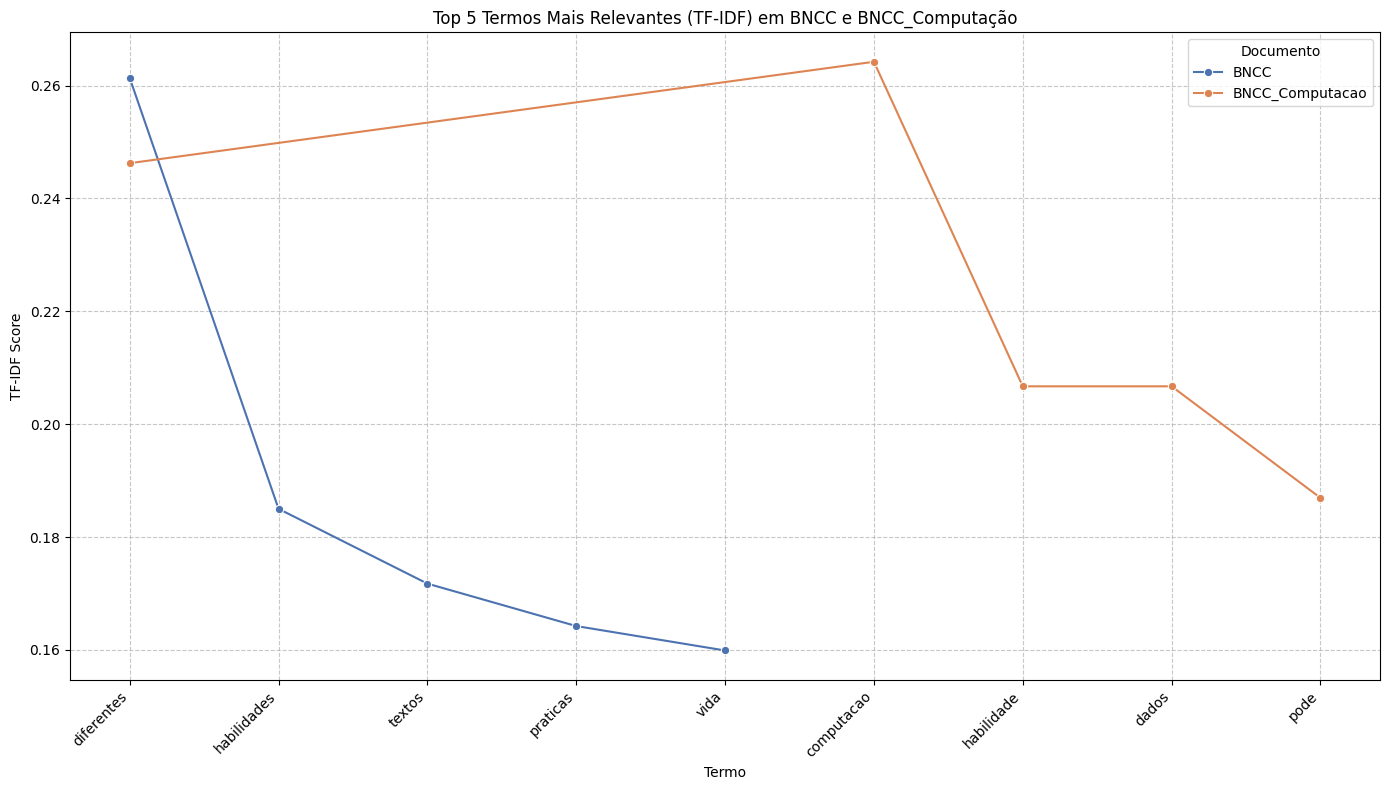

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregar os resultados TF-IDF para BNCC e BNCC_Computacao
df_bncc = pd.read_csv('TFIDF_BNCC.csv')
df_bncc_computacao = pd.read_csv('TFIDF_BNCC_Computacao.csv')

# Obter os 5 termos com maior TF-IDF para cada documento
df_bncc_top5 = df_bncc.head(5).copy()
df_bncc_computacao_top5 = df_bncc_computacao.head(5).copy()

# Adicionar uma coluna de identificação para cada documento
df_bncc_top5['Documento'] = 'BNCC'
df_bncc_computacao_top5['Documento'] = 'BNCC_Computacao'

# Combinar os dataframes
df_comparativo_top5 = pd.concat([df_bncc_top5, df_bncc_computacao_top5])

# Criar o gráfico de linha
plt.figure(figsize=(14, 8))
sns.lineplot(x='termo', y='tfidf', hue='Documento', data=df_comparativo_top5, marker='o', palette='deep')
plt.title('Top 5 Termos Mais Relevantes (TF-IDF) em BNCC e BNCC_Computação')
plt.xlabel('Termo')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Documento')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()